# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Sales Data Dataset](https://www.kaggle.com/datasets/vigneshpgd/indian-retail-sales-analytics-dataset/datas)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('sales_data.csv')

# Preprocessing

## Frist five row

In [3]:
pd.set_option('display.max_columns', None)
df.head()

,Order_ID,Order_Date,Customer_ID,Region,City,Segment,Channel,Category,Subcategory,Product_ID,Quantity,Unit_Price_INR,Discount,Sales_INR,Discount_Amount_INR,Net_Sales_INR,Cost_INR,Profit_INR,Shipping_Days,Returned,Customer_Satisfaction,Payment_Method
0,ORD111444,2024-01-01,CUST10128,West,Pune,Corporate,Online,Home & Kitchen,Appliances,P1046,2,327.15,0.00,654.30,0.00,654.30,387.43,266.87,1,No,4,Debit Card
1,ORD102034,2024-01-01,CUST10316,West,Ahmedabad,Corporate,Online,Beauty,Personal Care,P1048,1,1711.99,0.10,1711.99,171.20,1540.79,874.52,666.27,6,No,3,UPI
2,ORD106623,2024-01-01,CUST11764,South,Chennai,Consumer,Online,Home & Kitchen,Cookware,P1066,5,1180.95,0.05,5904.75,295.24,5609.51,3095.78,2513.74,3,No,3,Net Banking
3,ORD113951,2024-01-01,CUST12447,Central,Raipur,Consumer,Online,Home & Kitchen,Decor,P1057,2,703.24,0.15,1406.48,210.97,1195.51,720.77,474.74,4,No,3,Net Banking
4,ORD105177,2024-01-01,CUST10691,North,Chandigarh,Consumer,Online,Home & Kitchen,Decor,P1023,4,380.55,0.15,1522.20,228.33,1293.87,820.70,473.17,6,No,3,Credit Card


## last Five row

In [4]:
df.tail()

,Order_ID,Order_Date,Customer_ID,Region,City,Segment,Channel,Category,Subcategory,Product_ID,Quantity,Unit_Price_INR,Discount,Sales_INR,Discount_Amount_INR,Net_Sales_INR,Cost_INR,Profit_INR,Shipping_Days,Returned,Customer_Satisfaction,Payment_Method
14995,ORD109942,2025-12-31,CUST10397,West,Pune,Consumer,Online,Beauty,Skincare,P1004,6,2468.89,0.20,14813.34,2962.67,11850.67,5930.88,4262.25,4,Yes,3,Debit Card
14996,ORD101325,2025-12-31,CUST11524,South,Bengaluru,Consumer,Retail Store,Technology,Accessories,P1013,4,713.40,0.00,2853.60,0.00,2853.60,1985.23,868.37,5,No,3,Debit Card
14997,ORD107747,2025-12-31,CUST11321,East,Guwahati,Consumer,Online,Furniture,Chairs,P1022,2,1374.64,0.00,2749.28,0.00,2749.28,1795.97,953.31,2,No,3,Net Banking
14998,ORD105862,2025-12-31,CUST11426,East,Guwahati,Consumer,Online,Beauty,Personal Care,P1004,4,2504.95,0.25,10019.80,2504.95,7514.85,4022.03,3492.82,8,No,3,Credit Card
14999,ORD102445,2025-12-31,CUST10296,East,Kolkata,Consumer,Online,Office Supplies,Pens,P1055,7,833.00,0.30,5831.00,1749.30,4081.70,2212.60,1869.10,4,No,4,Credit Card


## Shape of our dataset

In [5]:
df.shape

(15000, 22)

## List out all columns

In [6]:
df.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Region', 'City', 'Segment',
       'Channel', 'Category', 'Subcategory', 'Product_ID', 'Quantity',
       'Unit_Price_INR', 'Discount', 'Sales_INR', 'Discount_Amount_INR',
       'Net_Sales_INR', 'Cost_INR', 'Profit_INR', 'Shipping_Days', 'Returned',
       'Customer_Satisfaction', 'Payment_Method'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

Order_ID                  object
Order_Date                object
Customer_ID               object
Region                    object
City                      object
Segment                   object
Channel                   object
Category                  object
Subcategory               object
Product_ID                object
Quantity                   int64
Unit_Price_INR           float64
Discount                 float64
Sales_INR                float64
Discount_Amount_INR      float64
Net_Sales_INR            float64
Cost_INR                 float64
Profit_INR               float64
Shipping_Days              int64
Returned                  object
Customer_Satisfaction      int64
Payment_Method            object
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Order_ID               15000 non-null  object 
 1   Order_Date             15000 non-null  object 
 2   Customer_ID            15000 non-null  object 
 3   Region                 15000 non-null  object 
 4   City                   15000 non-null  object 
 5   Segment                15000 non-null  object 
 6   Channel                15000 non-null  object 
 7   Category               15000 non-null  object 
 8   Subcategory            15000 non-null  object 
 9   Product_ID             15000 non-null  object 
 10  Quantity               15000 non-null  int64  
 11  Unit_Price_INR         15000 non-null  float64
 12  Discount               15000 non-null  float64
 13  Sales_INR              15000 non-null  float64
 14  Discount_Amount_INR    15000 non-null  float64
 15  Ne

## Check Null Value

In [9]:
df.isnull().sum()

Order_ID                 0
Order_Date               0
Customer_ID              0
Region                   0
City                     0
Segment                  0
Channel                  0
Category                 0
Subcategory              0
Product_ID               0
Quantity                 0
Unit_Price_INR           0
Discount                 0
Sales_INR                0
Discount_Amount_INR      0
Net_Sales_INR            0
Cost_INR                 0
Profit_INR               0
Shipping_Days            0
Returned                 0
Customer_Satisfaction    0
Payment_Method           0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,Quantity,Unit_Price_INR,Discount,Sales_INR,Discount_Amount_INR,Net_Sales_INR,Cost_INR,Profit_INR,Shipping_Days,Customer_Satisfaction
count,15000.000000,15000.00000,15000.000000,15000.000000,15000.00000,15000.000000,15000.000000,15000.000000,15000.000000,15000.00000
mean,3.991333,1347.45306,0.106630,5396.765599,578.66473,4818.100912,2960.555138,1818.571167,3.678133,3.54920
std,1.993370,973.90804,0.087742,5225.206681,863.70892,4700.051718,2919.123008,1821.210884,1.669228,0.73522
min,1.000000,150.00000,0.000000,150.000000,0.00000,119.780000,75.110000,39.230000,1.000000,1.00000
25%,2.000000,708.49000,0.050000,2033.355000,17.45500,1793.360000,1090.092500,663.167500,2.000000,3.00000
50%,4.000000,1092.60500,0.100000,3901.345000,298.30500,3462.510000,2110.155000,1279.100000,4.000000,4.00000
75%,6.000000,1692.42750,0.150000,6949.402500,745.05250,6230.482500,3812.557500,2334.192500,5.000000,4.00000
max,7.000000,18616.06000,0.300000,130312.420000,13031.24000,117281.180000,70176.380000,47104.800000,8.000000,5.00000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

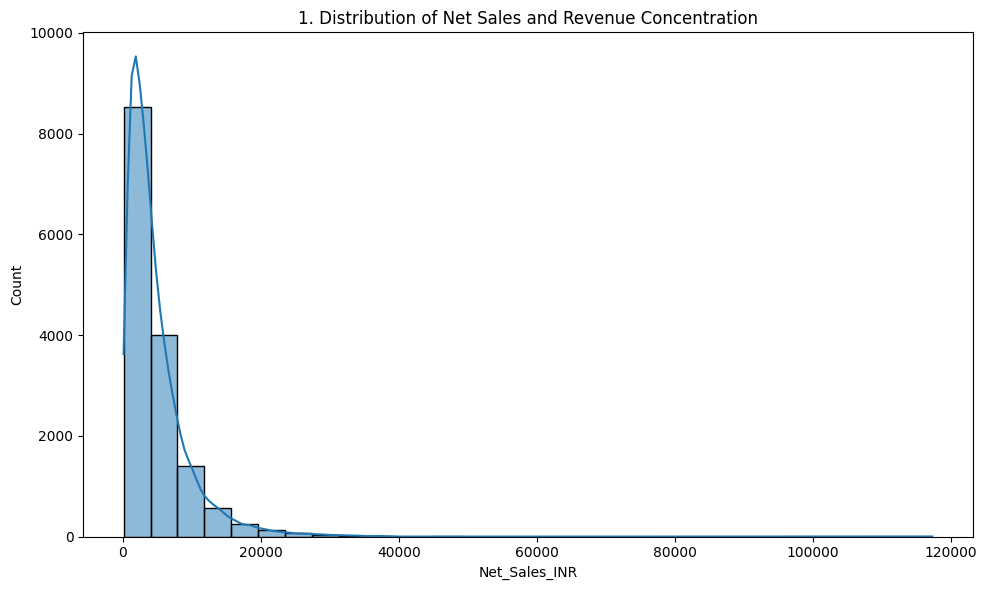

In [13]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Net_Sales_INR', kde=True, bins=30)
plt.title(f'{plot_no}. Distribution of Net Sales and Revenue Concentration')
show_fig()
plot_no += 1

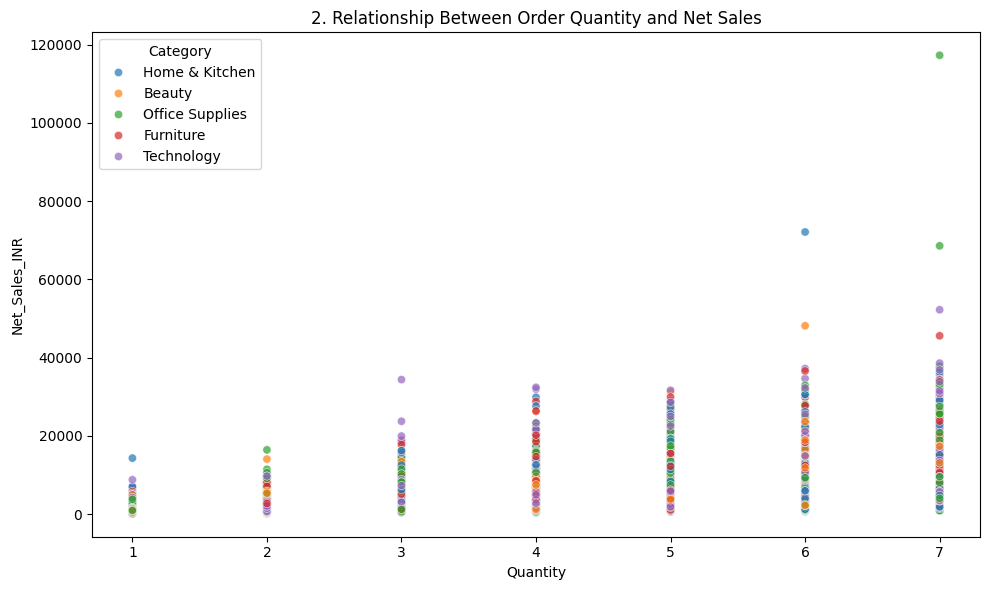

In [14]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Quantity', y='Net_Sales_INR', hue='Category', alpha=0.7)
plt.title(f'{plot_no}. Relationship Between Order Quantity and Net Sales')
show_fig()
plot_no += 1

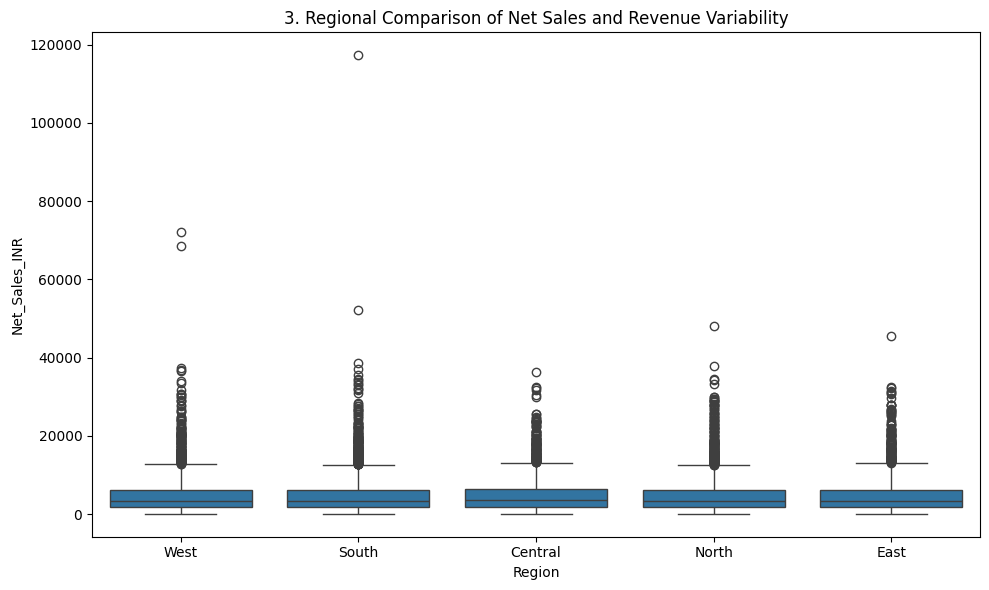

In [15]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Region', y='Net_Sales_INR')
plt.title(f'{plot_no}. Regional Comparison of Net Sales and Revenue Variability')
show_fig()
plot_no += 1

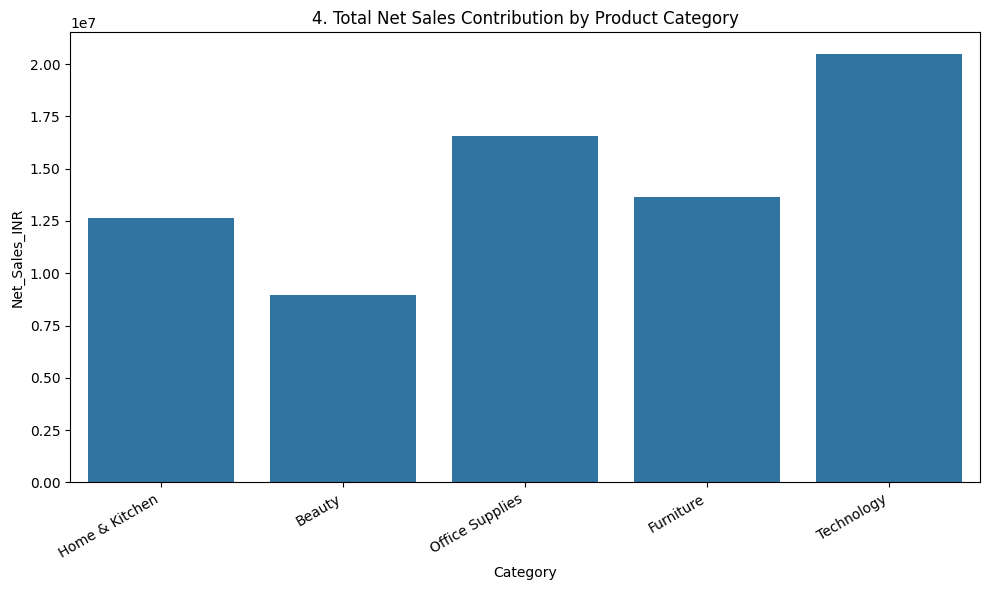

In [16]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Category', y='Net_Sales_INR', estimator='sum', errorbar=None)
plt.title(f'{plot_no}. Total Net Sales Contribution by Product Category')
plt.xticks(rotation=30, ha='right')
show_fig()
plot_no += 1

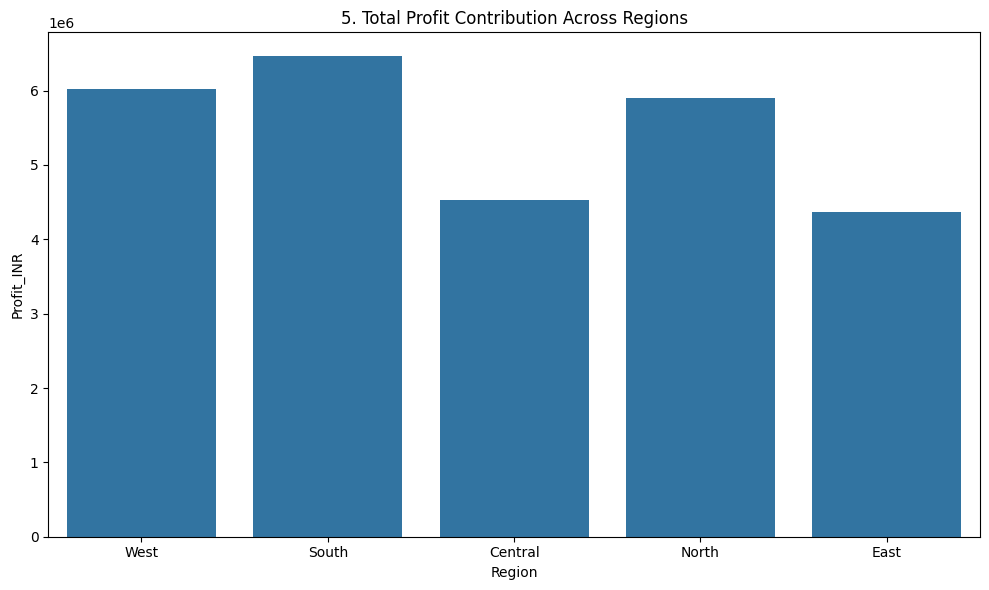

In [17]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Region', y='Profit_INR', estimator='sum', errorbar=None)
plt.title(f'{plot_no}. Total Profit Contribution Across Regions')
show_fig()
plot_no += 1

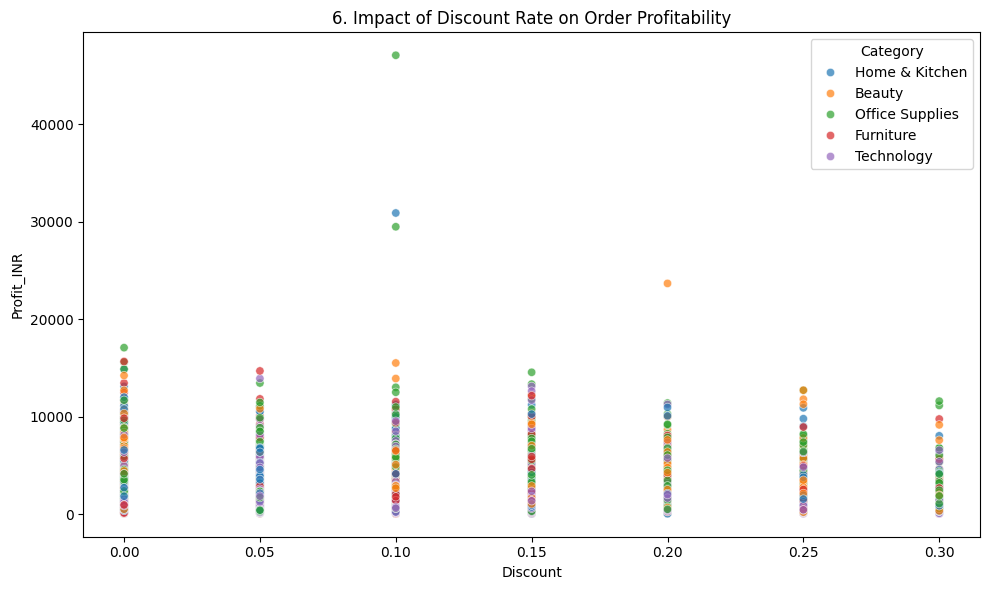

In [18]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Discount', y='Profit_INR', hue='Category', alpha=0.7)
plt.title(f'{plot_no}. Impact of Discount Rate on Order Profitability')
show_fig()
plot_no += 1

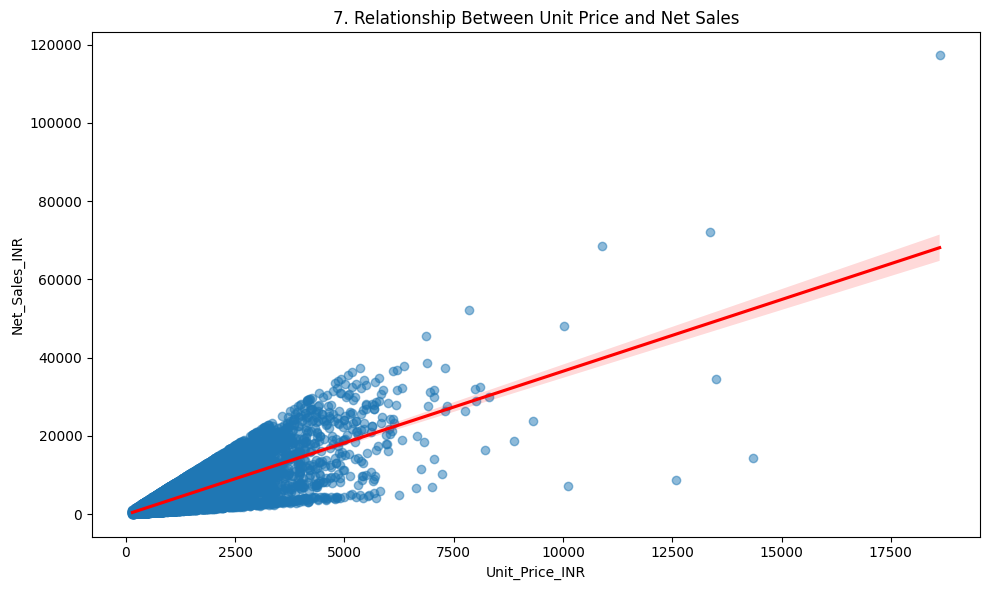

In [19]:
fig = plt.figure(figsize=(10,6))
sns.regplot(data=df, x='Unit_Price_INR', y='Net_Sales_INR', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title(f'{plot_no}. Relationship Between Unit Price and Net Sales')
show_fig()
plot_no += 1

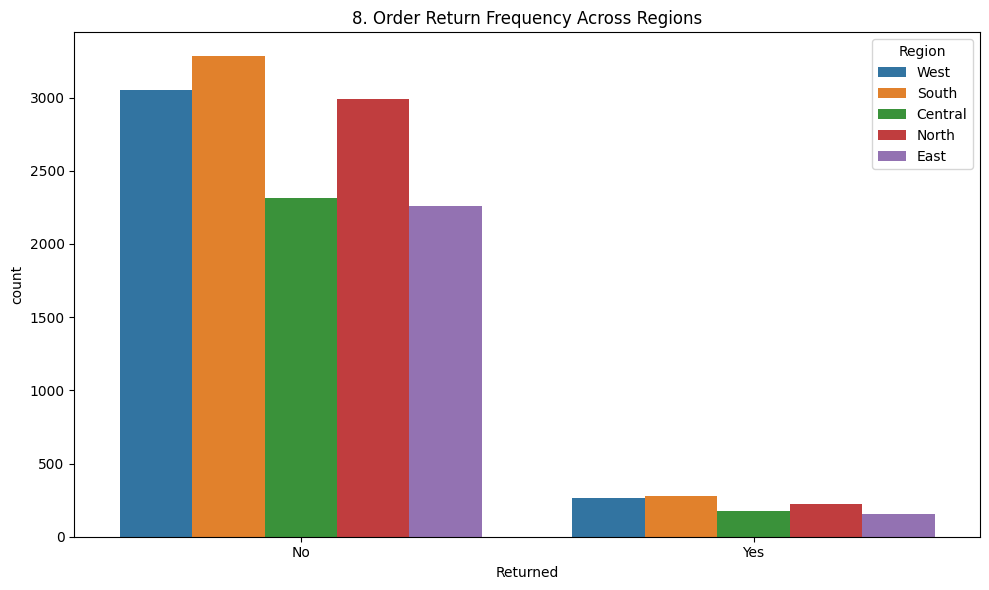

In [20]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Returned', hue='Region')
plt.title(f'{plot_no}. Order Return Frequency Across Regions')
show_fig()
plot_no += 1

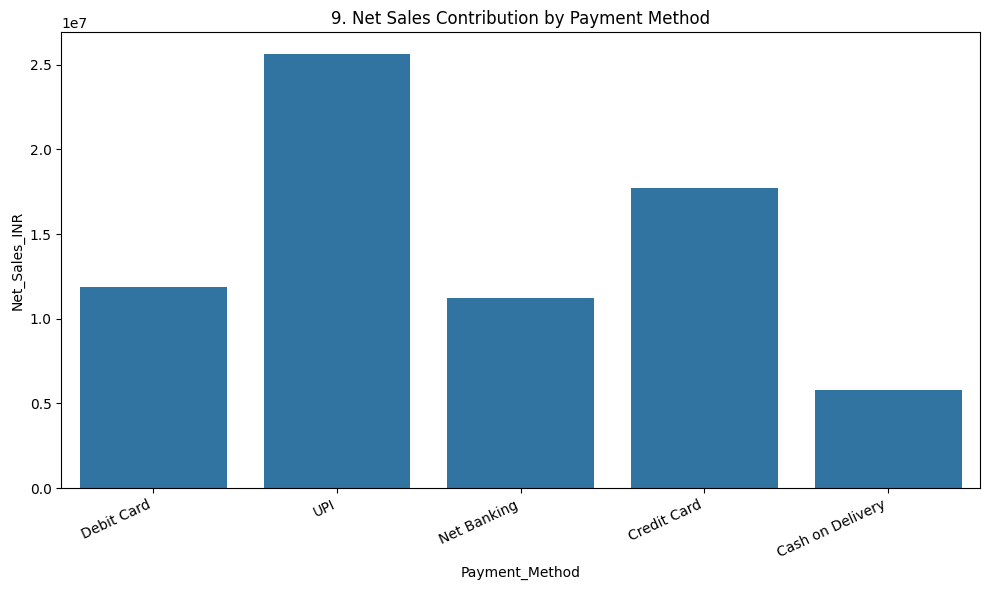

In [21]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Payment_Method', y='Net_Sales_INR', estimator='sum', errorbar=None)
plt.title(f'{plot_no}. Net Sales Contribution by Payment Method')
plt.xticks(rotation=25, ha='right')
show_fig()
plot_no += 1

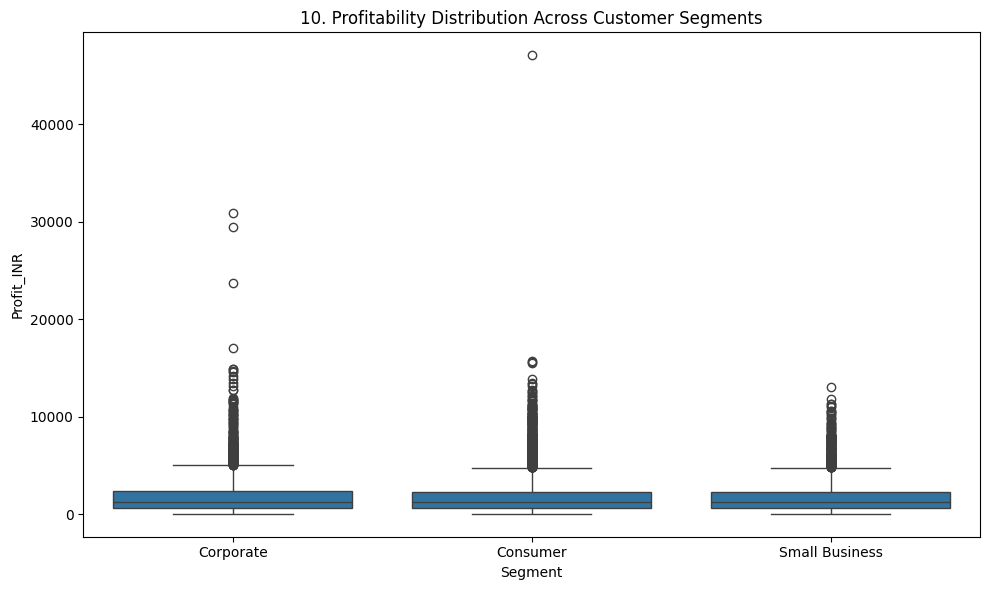

In [22]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Segment', y='Profit_INR')
plt.title(f'{plot_no}. Profitability Distribution Across Customer Segments')
show_fig()
plot_no += 1

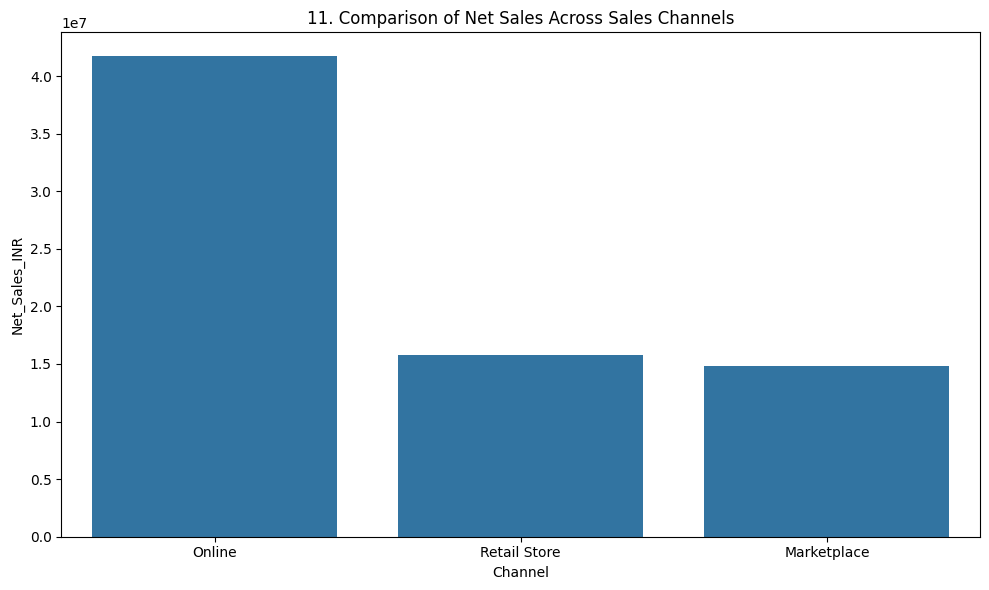

In [23]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Channel', y='Net_Sales_INR', estimator='sum', errorbar=None)
plt.title(f'{plot_no}. Comparison of Net Sales Across Sales Channels')
show_fig()
plot_no += 1

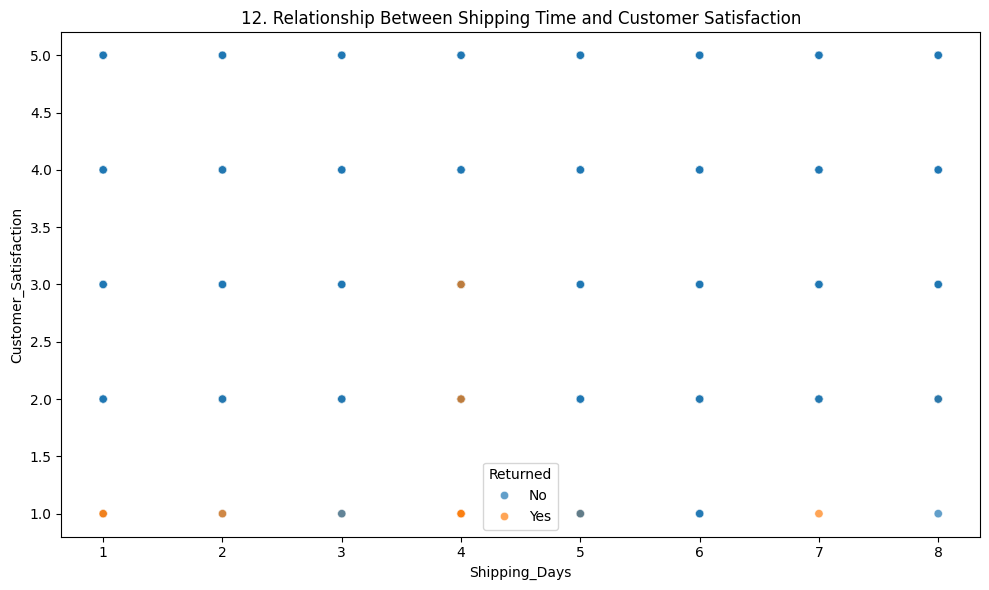

In [24]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Shipping_Days', y='Customer_Satisfaction', hue='Returned', alpha=0.7)
plt.title(f'{plot_no}. Relationship Between Shipping Time and Customer Satisfaction')
show_fig()
plot_no += 1

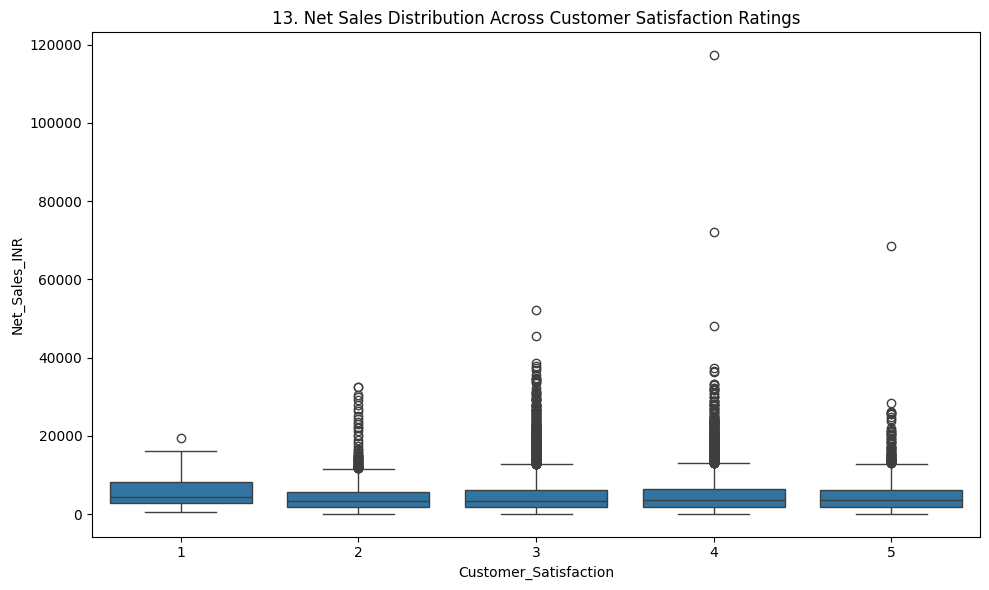

In [25]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Customer_Satisfaction', y='Net_Sales_INR')
plt.title(f'{plot_no}. Net Sales Distribution Across Customer Satisfaction Ratings')
show_fig()
plot_no += 1

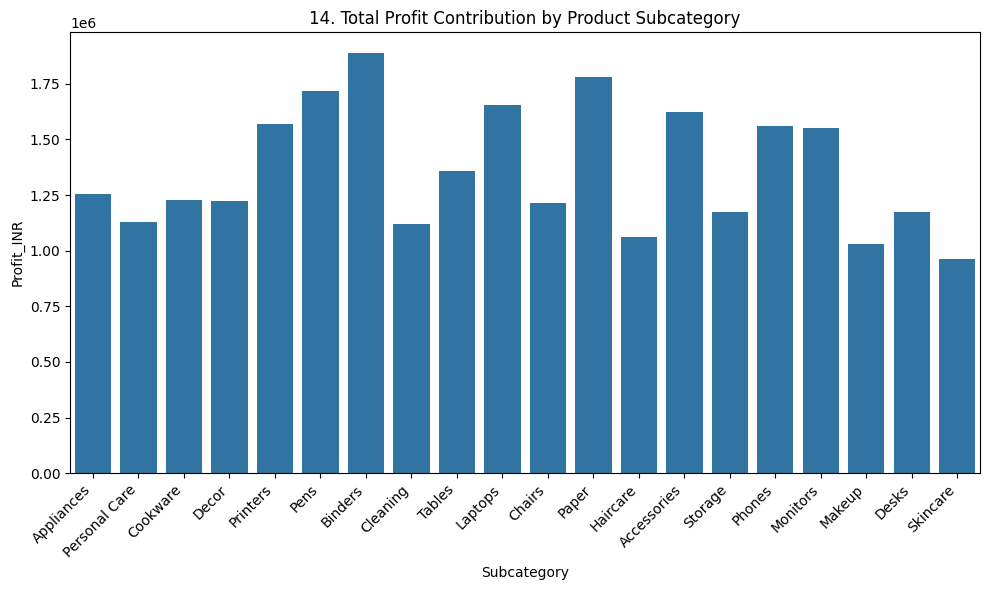

In [26]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Subcategory', y='Profit_INR', estimator='sum', errorbar=None)
plt.title(f'{plot_no}. Total Profit Contribution by Product Subcategory')
plt.xticks(rotation=45, ha='right')
show_fig()
plot_no += 1

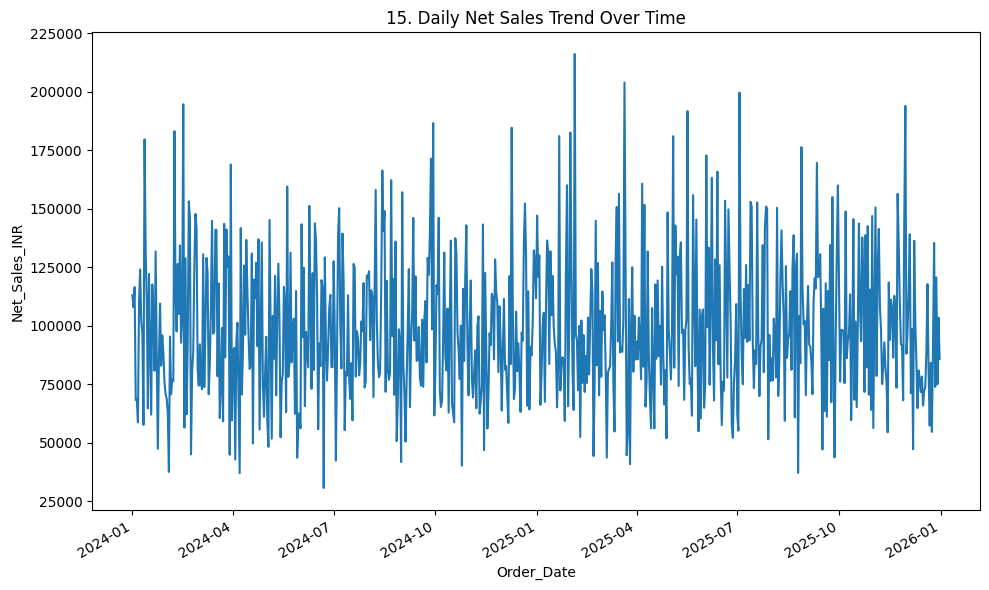

In [27]:
fig = plt.figure(figsize=(10,6))
sns.lineplot(data=df.assign(Order_Date=pd.to_datetime(df['Order_Date'])).groupby('Order_Date', as_index=False)['Net_Sales_INR'].sum(), x='Order_Date', y='Net_Sales_INR')
plt.title(f'{plot_no}. Daily Net Sales Trend Over Time')
plt.xticks(rotation=30, ha='right')
show_fig()
plot_no += 1

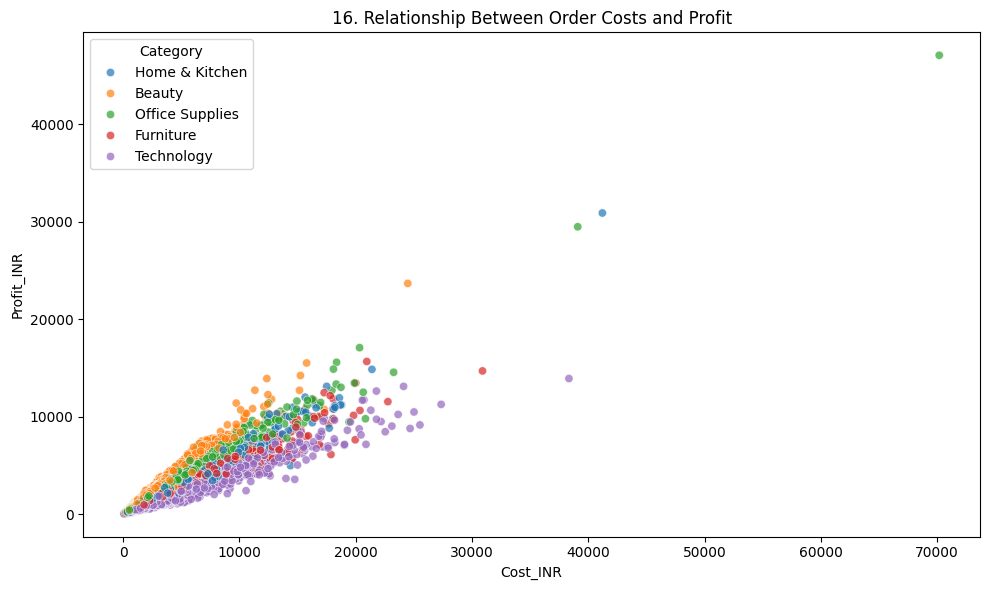

In [28]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Cost_INR', y='Profit_INR', hue='Category', alpha=0.7)
plt.title(f'{plot_no}. Relationship Between Order Costs and Profit')
show_fig()
plot_no += 1

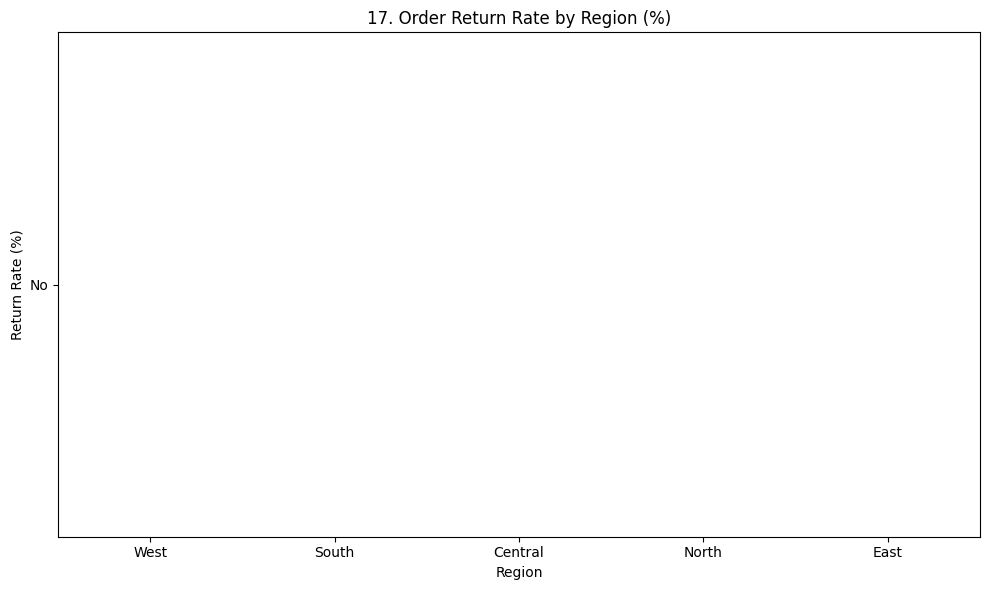

In [29]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Region', y='Returned', estimator=lambda x: (x == 'Yes').mean() * 100, errorbar=None)
plt.title(f'{plot_no}. Order Return Rate by Region (%)')
plt.ylabel('Return Rate (%)')
show_fig()
plot_no += 1

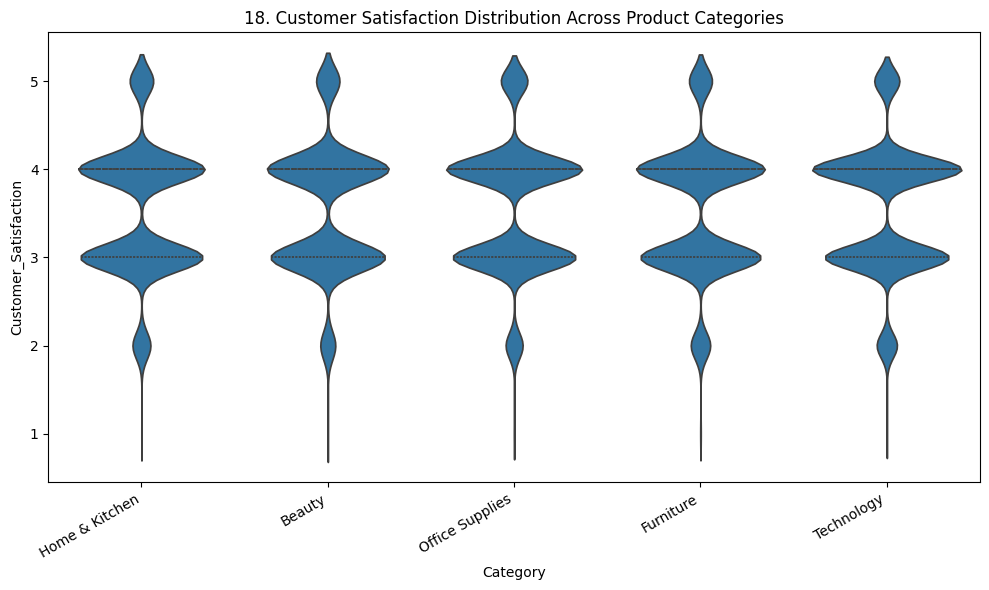

In [30]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='Category', y='Customer_Satisfaction', inner='quartile')
plt.title(f'{plot_no}. Customer Satisfaction Distribution Across Product Categories')
plt.xticks(rotation=30, ha='right')
show_fig()
plot_no += 1

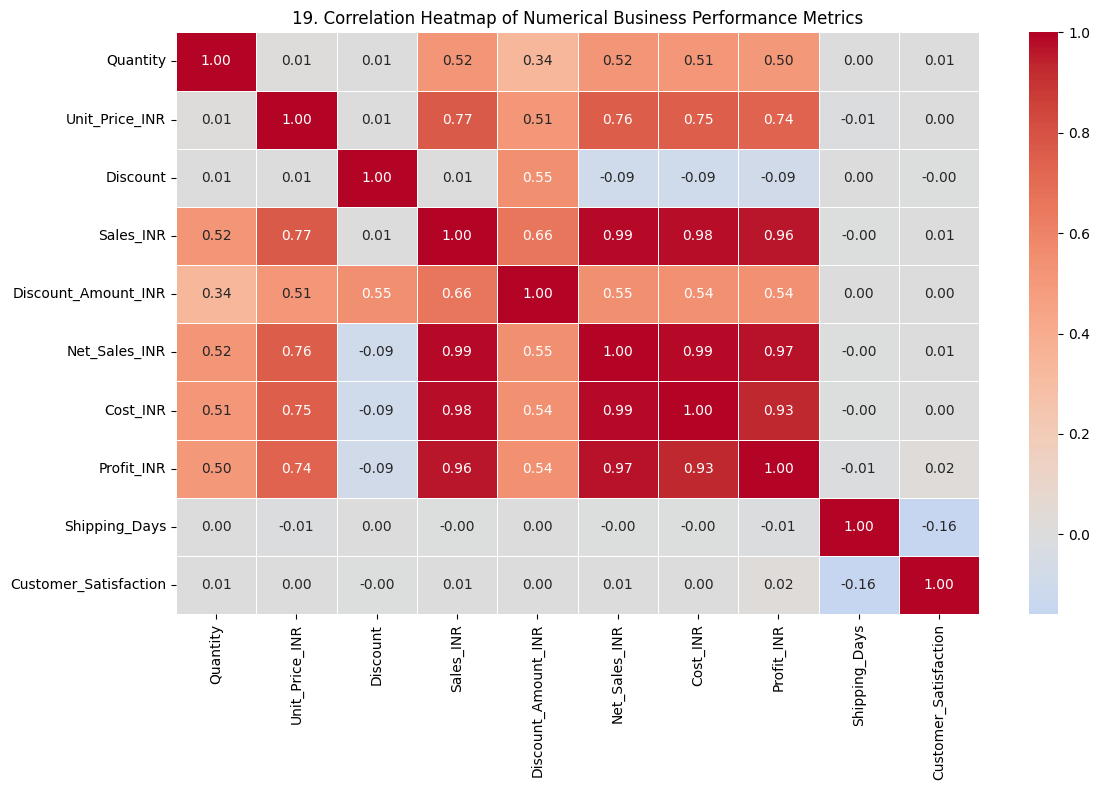

In [31]:
fig = plt.figure(figsize=(12,8))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, center=0)
plt.title(f'{plot_no}. Correlation Heatmap of Numerical Business Performance Metrics')
show_fig()
plot_no += 1

# Model Training

## Prepare features and target

In [32]:
data = df.copy()
data['Order_Date'] = pd.to_datetime(data['Order_Date'], errors='coerce')
data['Order_Year'] = data['Order_Date'].dt.year
data['Order_Month'] = data['Order_Date'].dt.month
data['Order_Day'] = data['Order_Date'].dt.day
data = data.drop(columns=['Order_Date', 'Order_ID', 'Customer_ID', 'Product_ID'], errors='ignore')
data['Profit_INR'] = pd.to_numeric(data['Profit_INR'], errors='coerce')
data = data.dropna(subset=['Profit_INR'])
X = data.drop(columns=['Profit_INR', 'Sales_INR', 'Net_Sales_INR', 'Cost_INR', 'Discount_Amount_INR'], errors='ignore')
y = data['Profit_INR']

## Identify numerical and categorical columns

In [33]:
num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()

## Build preprocessing pipelines

In [34]:
num_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
cat_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
preprocessor = ColumnTransformer([('num', num_pipe, num_cols), ('cat', cat_pipe, cat_cols)])

## Split the dataset into training and testing sets

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Train the regression model

In [36]:
model = Pipeline([('preprocessor', preprocessor), ('regressor', HistGradientBoostingRegressor(max_iter=200, learning_rate=0.08, max_leaf_nodes=15, l2_regularization=1.0, random_state=42))])
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Generate predictions and evaluate the model

In [37]:
y_pred = model.predict(X_test)
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"Mean Absolute Error: ₹{mean_absolute_error(y_test, y_pred):,.2f}")
print(f"Root Mean Squared Error: ₹{np.sqrt(mean_squared_error(y_test, y_pred)):,.2f}")

R² Score: 0.9626
Mean Absolute Error: ₹148.12
Root Mean Squared Error: ₹343.50


## Plot actual versus predicted profit

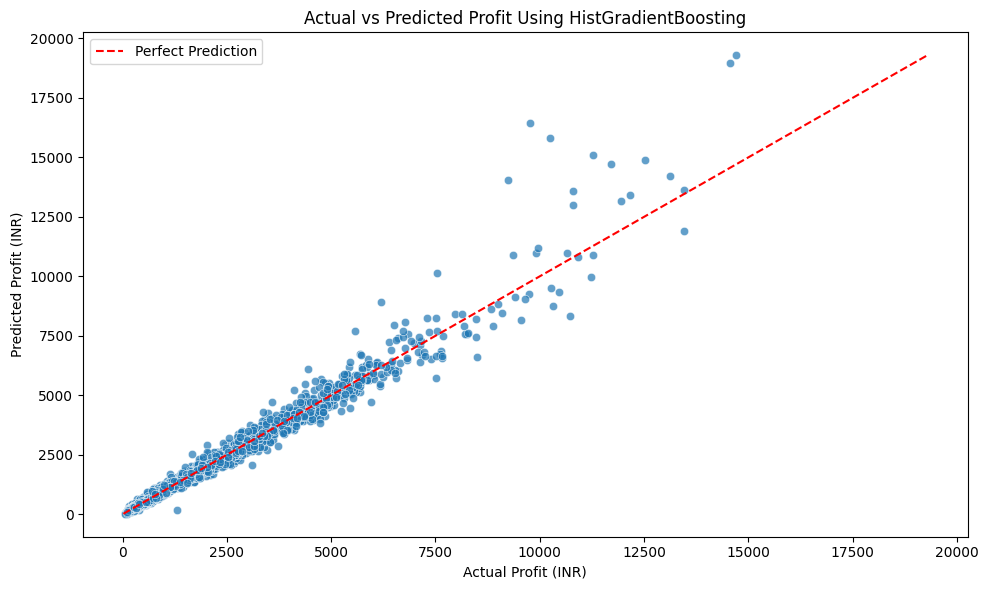

In [38]:
fig = plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', label='Perfect Prediction')
plt.xlabel('Actual Profit (INR)')
plt.ylabel('Predicted Profit (INR)')
plt.title('Actual vs Predicted Profit Using HistGradientBoosting')
plt.legend()
show_fig()